# 02 — Preprocessing

This notebook prepares the dataset for model training. It loads the raw image directories as TensorFlow datasets, applies normalization, sets up data augmentation, builds an efficient prefetch pipeline, and saves the class mapping to disk.

## Imports & Settings

Import all required libraries and fix the random seed for reproducibility.

In [ ]:
import os
import cv2
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# SETTINGS
warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Better plot appearance
plt.rcParams["figure.figsize"] = (10, 6)

print("TensorFlow version:", tf.__version__)

2026-05-09 18:51:39.864631: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-09 18:51:39.910215: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 18:51:40.979987: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.20.0


## Paths & Hyperparameters

Resolve dataset and output directories relative to the notebook location.

In [ ]:
import IPython

NOTEBOOK_DIR = Path(
    IPython.get_ipython().run_line_magic('pwd', '')
).resolve()

BASE_DIR = NOTEBOOK_DIR.parent / 'data'

TRAIN_DIR = BASE_DIR / 'processed' / 'train'
VAL_DIR   = BASE_DIR / 'processed' / 'val'
TEST_DIR  = BASE_DIR / 'processed' / 'test'

OUT_DIR = BASE_DIR.parent / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)


# HYPERPARAMETERS
IMG_SIZE     = 128
BATCH_SIZE   = 64

EPOCHS_CNN   = 50
EPOCHS_P1    = 10
EPOCHS_P2    = 30

LR_INIT      = 1e-3
LR_FINE      = 1e-5

NUM_CLASSES  = 29

AUTOTUNE     = tf.data.AUTOTUNE

print(f"Train dir : {TRAIN_DIR}")
print(f"Val dir   : {VAL_DIR}")
print(f"Test dir  : {TEST_DIR}")
print(f"Output dir: {OUT_DIR}")

Train dir : /media/bakhom-ramzy/Windows E/A-university/Sem-2/img-processing/SignLanguageTranslator/SignLanguageTranslator/project/data/processed/train
Val dir   : /media/bakhom-ramzy/Windows E/A-university/Sem-2/img-processing/SignLanguageTranslator/SignLanguageTranslator/project/data/processed/val
Test dir  : /media/bakhom-ramzy/Windows E/A-university/Sem-2/img-processing/SignLanguageTranslator/SignLanguageTranslator/project/data/processed/test
Output dir: /media/bakhom-ramzy/Windows E/A-university/Sem-2/img-processing/SignLanguageTranslator/SignLanguageTranslator/project/outputs


## Load Datasets

Load train, validation, and test sets from directory structure using `image_dataset_from_directory`.

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 4031 files belonging to 29 classes.
Found 870 files belonging to 29 classes.
Found 899 files belonging to 29 classes.


2026-05-09 18:51:43.067395: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## Class Names

In [ ]:
class_names = train_ds.class_names

print(class_names)

print("\nNumber of classes:", len(class_names))

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']

Number of classes: 29


## Visualize a Training Batch

Display a 4×4 grid of sample images with their class labels.

2026-05-09 18:51:43.336635: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


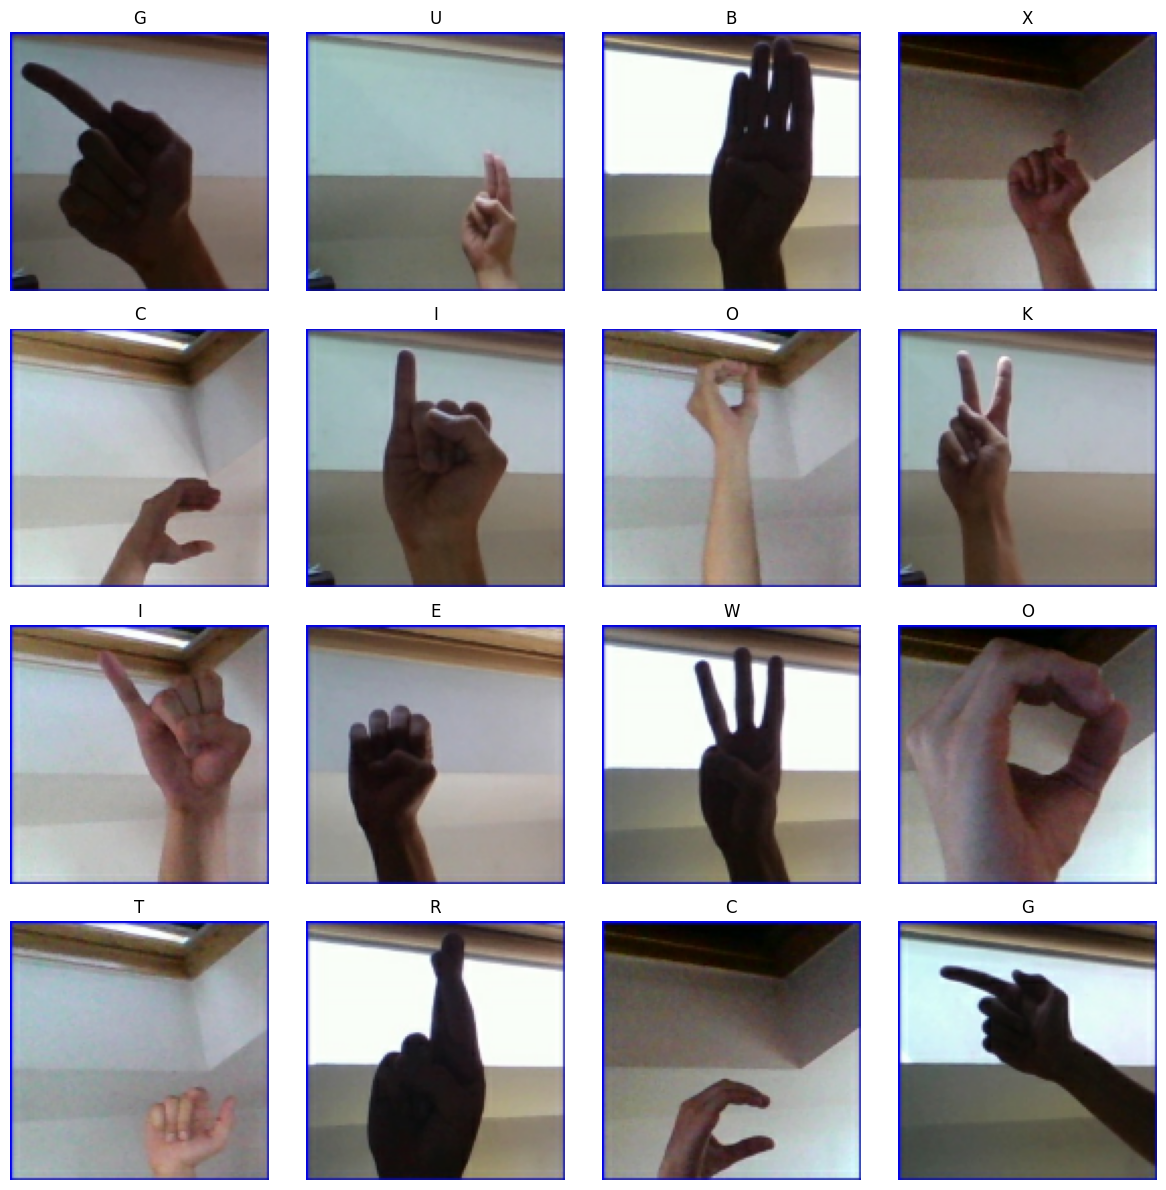

In [ ]:
plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):

    for i in range(16):

        ax = plt.subplot(4, 4, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels[i]]
        )

        plt.axis("off")

plt.tight_layout()

plt.show()

## Normalization Layer

Create a rescaling layer that maps pixel values from `[0, 255]` to `[0, 1]`.

In [ ]:
normalization_layer = layers.Rescaling(1./255)

## Data Augmentation

Define random augmentations (rotation, zoom, translation, contrast) applied during training to improve generalization.

In [ ]:
data_augmentation = tf.keras.Sequential([

    layers.RandomRotation(0.05),

    layers.RandomZoom(0.1),

    layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    ),

    layers.RandomContrast(0.1)

])

## Visualize Augmentation

Apply augmentation 9 times to a single image to inspect the variation produced.

2026-05-09 18:51:44.565031: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


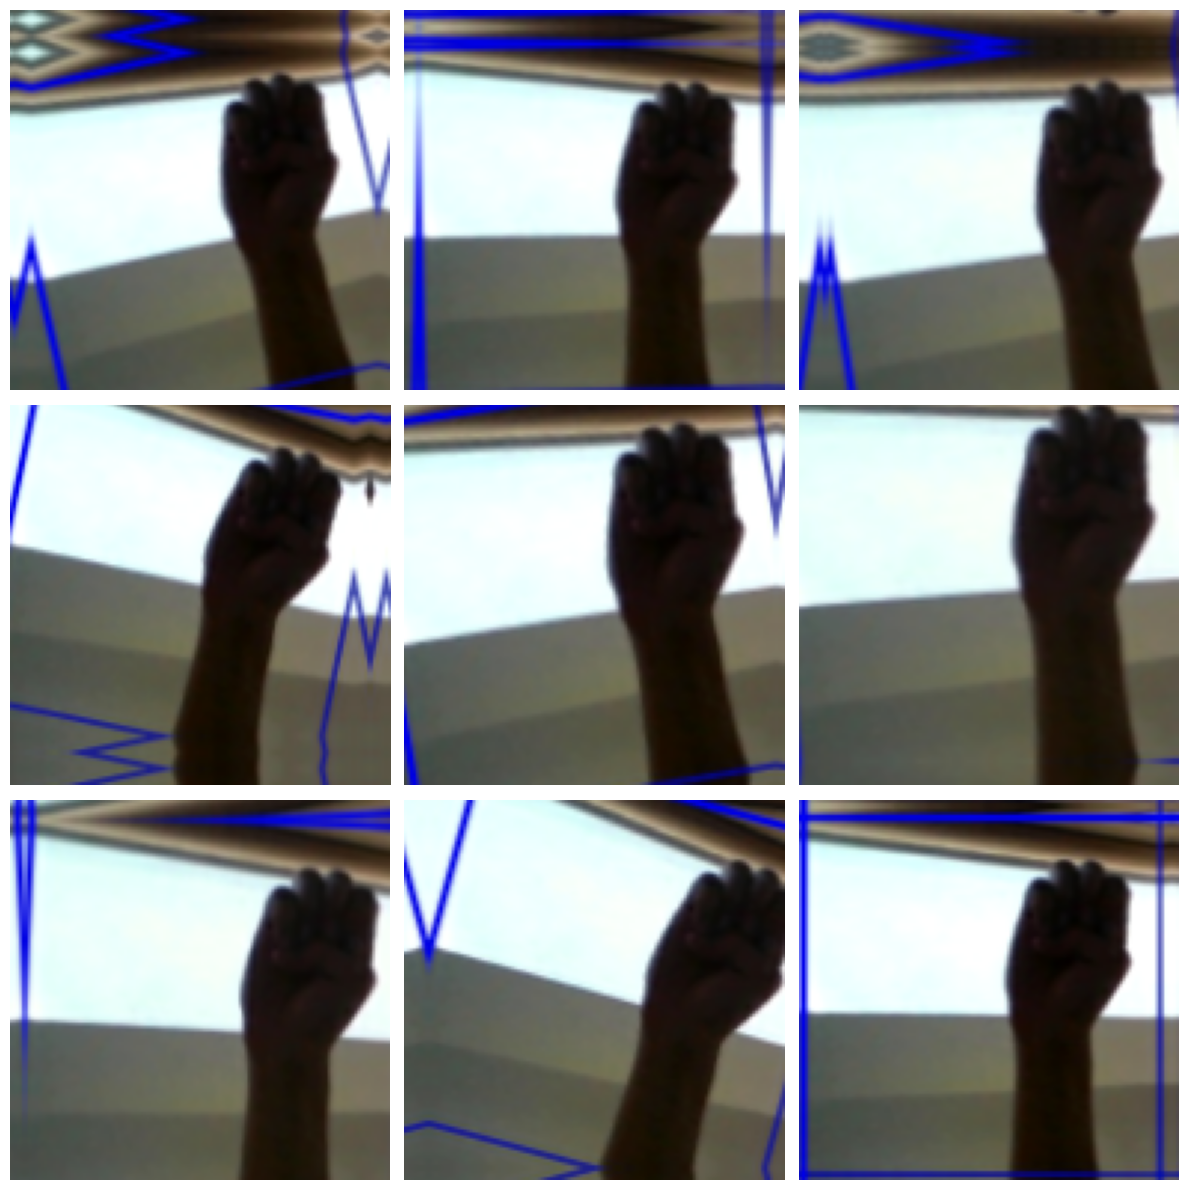

In [ ]:
for images, labels in train_ds.take(1):

    sample_image = images[0]

    plt.figure(figsize=(12,12))

    for i in range(9):

        augmented = data_augmentation(
            tf.expand_dims(sample_image, 0)
        )

        ax = plt.subplot(3,3,i+1)

        plt.imshow(
            augmented[0].numpy().astype("uint8")
        )

        plt.axis("off")

plt.tight_layout()

plt.show()

## Apply Normalization to All Splits

Map the normalization function across train, val, and test datasets.

In [ ]:
normalization_layer = layers.Rescaling(1./255)

def preprocess(image, label):
    image = normalization_layer(image)
    return image, label


train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
val_ds   = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
test_ds  = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE)

## Prefetch Pipeline

Enable `prefetch` with `AUTOTUNE` to overlap data loading and model training, preventing GPU starvation.

In [ ]:
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

## Verify Dataset Shapes & Pixel Range

In [ ]:
for images, labels in train_ds.take(1):

    print("Images shape :", images.shape)

    print("Labels shape :", labels.shape)

    print("Min pixel value :", tf.reduce_min(images).numpy())

    print("Max pixel value :", tf.reduce_max(images).numpy())

Images shape : (64, 128, 128, 3)
Labels shape : (64,)
Min pixel value : 0.0
Max pixel value : 1.0


## Save Class Mapping

Persist the `{index: class_name}` mapping as a JSON file for use in evaluation.

In [ ]:
metadata_dir = BASE_DIR / "metadata"
metadata_dir.mkdir(parents=True, exist_ok=True)  # IMPORTANT FIX

class_mapping = {
    idx: name
    for idx, name in enumerate(class_names)
}

mapping_path = metadata_dir / "class_mapping.json"

with open(mapping_path, "w") as f:
    json.dump(class_mapping, f, indent=4)

print("Saved to:", mapping_path)

Saved to: /media/bakhom-ramzy/Windows E/A-university/Sem-2/img-processing/SignLanguageTranslator/SignLanguageTranslator/project/data/metadata/class_mapping.json


In [ ]:
metadata_dir = BASE_DIR / "metadata"
metadata_dir.mkdir(parents=True, exist_ok=True)

class_mapping = {
    idx: name
    for idx, name in enumerate(class_names)
}

mapping_path = metadata_dir / "class_mapping.json"

with open(mapping_path, "w") as f:
    json.dump(class_mapping, f, indent=4)

print("Class mapping saved to:", mapping_path)

Class mapping saved to: /media/bakhom-ramzy/Windows E/A-university/Sem-2/img-processing/SignLanguageTranslator/SignLanguageTranslator/project/data/metadata/class_mapping.json
